# Clusterização de Risco de Ativos
**Objetivo:** Descobrir grupos de risco automaticamente a partir dos retornos diários.

**Fluxo:**
1. Carregar retornos diários
2. Extrair features por ativo
3. K-Means → grupos de risco
4. PCA → reduzir para 2D
5. Scatter plot colorido por cluster

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

## 1. Carregar dados
Espera um CSV com:
- Linhas = dias
- Colunas = ativos (ex: PETR4, VALE3...)
- Valores = retornos diários (ex: 0.012 = +1,2%)

In [20]:
# ── ALTERE O CAMINHO ABAIXO ──────────────────────────────────────────
CAMINHO_CSV = r"C:\Users\DECIV\Documents\GitHub\mestrado\base_dados\retornos_ativos2.csv"
COLUNA_DATA = 'Date'   # nome da coluna de data (ou None se não existir)
# ─────────────────────────────────────────────────────────────────────

if COLUNA_DATA:
    df = pd.read_csv(CAMINHO_CSV).set_index(COLUNA_DATA)
else:
    df = pd.read_csv(CAMINHO_CSV)

df = df.dropna(axis=1, thresh=int(len(df) * 0.8))  # remove ativos com >20% NaN
df = df.fillna(0)

print(f"Retornos carregados: {df.shape[0]} dias × {df.shape[1]} ativos")
df.head()

Retornos carregados: 248 dias × 80 ativos


,VALE3.SA,ITUB4.SA,PETR4.SA,PETR3.SA,AXIA3.SA,BBDC4.SA,SBSP3.SA,B3SA3.SA,ITSA4.SA,BPAC11.SA,...,AZZA3.SA,RECV3.SA,USIM5.SA,HAPV3.SA,CEAB3.SA,BRKM5.SA,BEEF3.SA,VAMO3.SA,PCAR3.SA,RAIZ4.SA
Date,,,,,,,,,,,,,,,,,,,,,
2025-02-26,-0.006133,-0.002435,0.000000,-0.001682,-0.004783,-0.019541,-0.016343,-0.014815,-0.004430,-0.001233,...,-0.033550,-0.012763,0.010152,-0.014085,-0.023991,-0.022672,-0.013793,-0.032710,-0.044610,-0.016949
2025-02-27,-0.007405,-0.000915,-0.035309,-0.055595,-0.005340,-0.006066,-0.004984,0.005639,0.003337,-0.010806,...,0.010452,0.056884,-0.001675,0.009524,0.101676,-0.021541,0.048951,-0.014493,0.019455,-0.005747
2025-02-28,-0.020426,-0.024435,-0.018574,-0.004842,0.026040,-0.020052,-0.008766,-0.028037,-0.025499,-0.014357,...,-0.039527,-0.028135,-0.041946,-0.004717,0.001014,-0.071126,-0.017778,-0.066176,-0.034351,-0.046243
2025-03-05,0.007978,0.014963,-0.036460,-0.046095,0.000523,0.020463,-0.009160,0.012500,0.009958,0.011400,...,-0.009615,-0.031466,0.024518,0.009479,-0.021277,-0.032817,0.045249,-0.028871,-0.011858,0.036364
2025-03-06,0.010973,0.001852,-0.010399,-0.007517,0.011245,0.008677,0.000531,0.010446,0.004530,-0.015341,...,0.003107,0.003249,0.011966,-0.023474,-0.002070,-0.001885,0.030303,-0.013514,-0.028000,-0.005848


## 2. Extrair features por ativo
Cada ativo vira uma linha com estas features:

| Feature | O que captura |
|---|---|
| `retorno_medio` | Tendência de ganho |
| `volatilidade` | Risco total |
| `sharpe` | Retorno ajustado ao risco |
| `max_drawdown` | Pior queda consecutiva |
| `skewness` | Assimetria dos retornos |
| `kurtosis` | Frequência de retornos extremos |
| `downside_vol` | Volatilidade só dos dias negativos |
| `var_95` | Value at Risk — pior 5% dos dias |

In [21]:
def max_drawdown(retornos):
    """Calcula o máximo drawdown de uma série de retornos."""
    acum = (1 + retornos).cumprod()
    pico = acum.cummax()
    dd = (acum - pico) / pico
    return dd.min()

features = pd.DataFrame(index=df.columns)

features['retorno_medio']  = df.mean()                            # retorno médio diário
features['volatilidade']   = df.std()                             # desvio padrão diário
features['sharpe']         = df.mean() / df.std()                 # Sharpe simplificado
features['max_drawdown']   = df.apply(max_drawdown)               # pior queda acumulada
features['skewness']       = df.skew()                            # assimetria
features['kurtosis']       = df.kurt()                            # caudas pesadas
features['downside_vol']   = df[df < 0].std()                    # vol só dos dias ruins
features['var_95']         = df.quantile(0.05)                   # VaR 95%

features = features.fillna(0)

print(f"Features extraídas para {len(features)} ativos")
features.round(4).head(10)

Features extraídas para 80 ativos


,retorno_medio,volatilidade,sharpe,max_drawdown,skewness,kurtosis,downside_vol,var_95
VALE3.SA,0.0025,0.0152,0.1614,-0.1539,-0.0440,1.8913,0.0107,-0.0235
ITUB4.SA,0.0024,0.0135,0.1804,-0.0920,-0.0184,1.3722,0.0088,-0.0201
PETR4.SA,0.0007,0.0153,0.0471,-0.1991,-0.5825,2.3548,0.0120,-0.0256
PETR3.SA,0.0007,0.0174,0.0387,-0.2177,-0.7123,2.9384,0.0138,-0.0281
AXIA3.SA,0.0026,0.0214,0.1232,-0.2701,-4.6145,52.9778,0.0232,-0.0173
BBDC4.SA,0.0029,0.0176,0.1633,-0.0826,2.5135,22.9087,0.0094,-0.0199
SBSP3.SA,0.0024,0.0158,0.1489,-0.1131,0.9409,6.9187,0.0091,-0.0202
B3SA3.SA,0.0025,0.0218,0.1149,-0.1761,0.8641,4.4759,0.0126,-0.0295
ITSA4.SA,0.0025,0.0135,0.1863,-0.0908,0.0552,0.9829,0.0085,-0.0192
BPAC11.SA,0.0029,0.0190,0.1523,-0.1022,0.6778,9.2912,0.0128,-0.0257


## 3. Escolher número de clusters (método do cotovelo)
O gráfico mostra onde o ganho de adicionar mais clusters começa a diminuir.
Escolha o K no "cotovelo" da curva.

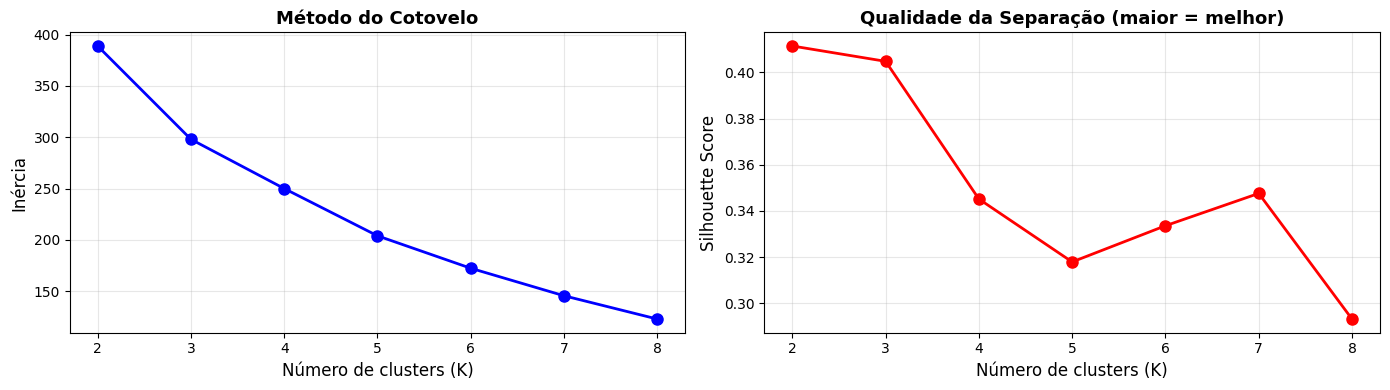

Escolha o K no cotovelo e ajuste K_ESCOLHIDO abaixo


In [23]:
# Normalizar features (importante para K-Means)
scaler = StandardScaler()
X = scaler.fit_transform(features)

# Testar K de 2 a 8
inertias = []
silhouettes = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Gráfico do cotovelo
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Número de clusters (K)', fontsize=12)
axes[0].set_ylabel('Inércia', fontsize=12)
axes[0].set_title('Método do Cotovelo', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Silhouette score (quanto maior, melhor a separação)
axes[1].plot(K_range, silhouettes, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Número de clusters (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Qualidade da Separação (maior = melhor)', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cotovelo.png', dpi=150, bbox_inches='tight')
plt.show()
print("Escolha o K no cotovelo e ajuste K_ESCOLHIDO abaixo")

## 4. Aplicar K-Means com K escolhido

In [34]:
# ── AJUSTE O K APÓS VER O GRÁFICO ACIMA ──────────────────────────────
K_ESCOLHIDO = 3   # número de grupos de risco
# ─────────────────────────────────────────────────────────────────────

kmeans = KMeans(n_clusters=K_ESCOLHIDO, random_state=42, n_init=10)
features['cluster'] = kmeans.fit_predict(X)

# Ordenar clusters por volatilidade média (cluster 0 = menor risco)
ordem = features.groupby('cluster')['volatilidade'].mean().sort_values().index
mapa = {old: new for new, old in enumerate(ordem)}
features['cluster'] = features['cluster'].map(mapa)

nomes_risco = {0: 'Baixo Risco', 1: 'Médio Risco', 2: 'Alto Risco'}
if K_ESCOLHIDO == 4:
    nomes_risco = {0: 'Muito Baixo', 1: 'Baixo', 2: 'Alto', 3: 'Muito Alto'}
features['risco'] = features['cluster'].map(nomes_risco)

print(f"Distribuição dos clusters:")
print(features['risco'].value_counts())

Distribuição dos clusters:
risco
Baixo Risco    52
Médio Risco    26
Alto Risco      2
Name: count, dtype: int64


## 5. Scatter Plot — Retorno vs Volatilidade (colorido por cluster)

In [35]:
features['risco']

VALE3.SA    Baixo Risco
ITUB4.SA    Baixo Risco
PETR4.SA    Baixo Risco
PETR3.SA    Baixo Risco
AXIA3.SA     Alto Risco
               ...     
BRKM5.SA    Médio Risco
BEEF3.SA    Médio Risco
VAMO3.SA    Médio Risco
PCAR3.SA    Médio Risco
RAIZ4.SA    Médio Risco
Name: risco, Length: 80, dtype: object

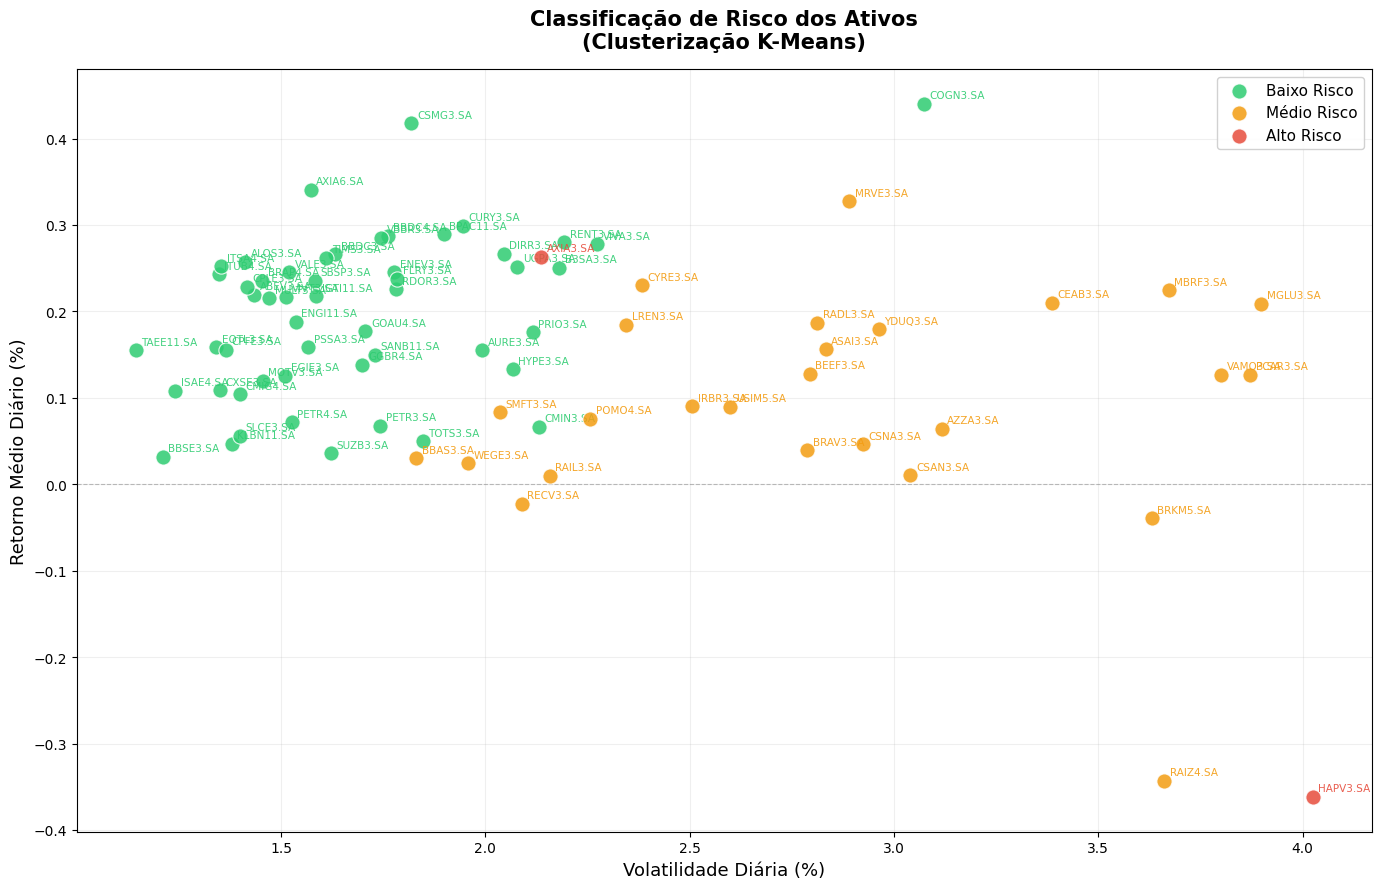

In [37]:
cores = ['#2ecc71', '#f39c12', '#e74c3c', '#9b59b6']  # verde, laranja, vermelho, roxo
clusters_unicos = sorted(features['cluster'].unique())

fig, ax = plt.subplots(figsize=(14, 9))

for i, cluster_id in enumerate(clusters_unicos):
    mask = features['cluster'] == cluster_id
    grupo = features[mask]
    nome  = nomes_risco.get(cluster_id, f'Grupo {cluster_id}')
    
    ax.scatter(
        grupo['volatilidade'] * 100,       # eixo X: volatilidade em %
        grupo['retorno_medio'] * 100,      # eixo Y: retorno médio em %
        c=cores[i],
        label=nome,
        s=120,
        alpha=0.85,
        edgecolors='white',
        linewidth=0.8,
        zorder=3
    )
    
    # Etiqueta de cada ativo
    for ativo in grupo.index:
        ax.annotate(
            ativo,
            xy=(grupo.loc[ativo, 'volatilidade'] * 100,
                grupo.loc[ativo, 'retorno_medio'] * 100),
            xytext=(4, 4),
            textcoords='offset points',
            fontsize=7.5,
            color=cores[i],
            alpha=0.9
        )

ax.axhline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xlabel('Volatilidade Diária (%)', fontsize=13)
ax.set_ylabel('Retorno Médio Diário (%)', fontsize=13)
ax.set_title('Classificação de Risco dos Ativos\n(Clusterização K-Means)', 
             fontsize=15, fontweight='bold', pad=15)
ax.legend(fontsize=11, framealpha=0.9)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('scatter_risco_ativos.png', dpi=180, bbox_inches='tight')
plt.show()

## 6. Scatter Plot PCA — visão do espaço de todas as features
O PCA comprime as 8 features em 2 dimensões para visualização.

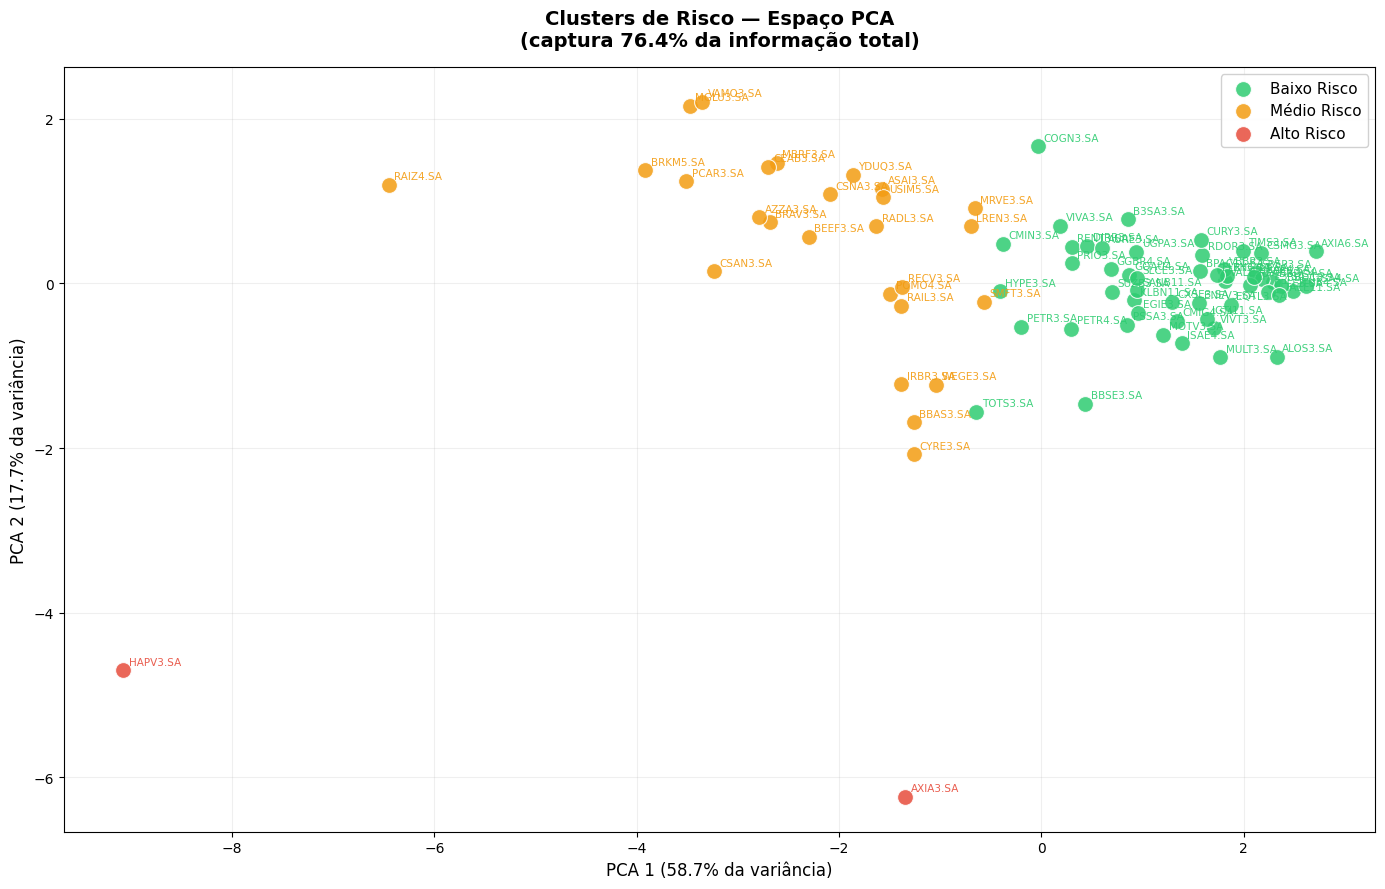

In [39]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X)
variancia = pca.explained_variance_ratio_

features['pca1'] = coords[:, 0]
features['pca2'] = coords[:, 1]

fig, ax = plt.subplots(figsize=(14, 9))

for i, cluster_id in enumerate(clusters_unicos):
    mask = features['cluster'] == cluster_id
    grupo = features[mask]
    nome  = nomes_risco.get(cluster_id, f'Grupo {cluster_id}')
    
    ax.scatter(
        grupo['pca1'], grupo['pca2'],
        c=cores[i], label=nome,
        s=130, alpha=0.85,
        edgecolors='white', linewidth=0.8, zorder=3
    )
    
    for ativo in grupo.index:
        ax.annotate(
            ativo,
            xy=(grupo.loc[ativo, 'pca1'], grupo.loc[ativo, 'pca2']),
            xytext=(4, 4), textcoords='offset points',
            fontsize=7.5, color=cores[i], alpha=0.9
        )

ax.set_xlabel(f'PCA 1 ({variancia[0]*100:.1f}% da variância)', fontsize=12)
ax.set_ylabel(f'PCA 2 ({variancia[1]*100:.1f}% da variância)', fontsize=12)
ax.set_title(f'Clusters de Risco — Espaço PCA\n'
             f'(captura {(variancia[0]+variancia[1])*100:.1f}% da informação total)',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=11, framealpha=0.9)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('pca_risco_ativos.png', dpi=180, bbox_inches='tight')
plt.show()

## 7. Perfil de cada cluster
Média das features por grupo — ajuda a interpretar o que cada cluster representa.

In [58]:
cols_perfil = ['retorno_medio', 'volatilidade', 'sharpe', 'max_drawdown', 
               'skewness', 'downside_vol', 'var_95']

perfil = features.groupby('risco')[cols_perfil].mean()

# Formatar para exibição
perfil_fmt = perfil.copy()
for col in ['retorno_medio', 'volatilidade', 'max_drawdown', 'downside_vol', 'var_95']:
    perfil_fmt[col] = (perfil[col] * 100).round(3).astype(str) + '%'
perfil_fmt['sharpe']   = perfil['sharpe'].round(4)
perfil_fmt['skewness'] = perfil['skewness'].round(3)

print("Perfil médio por grupo de risco:")
perfil_fmt

Perfil médio por grupo de risco:


,retorno_medio,volatilidade,sharpe,max_drawdown,skewness,downside_vol,var_95
risco,,,,,,,
Alto Risco,-0.049%,3.081%,0.0166,-52.122%,-4.457,3.095%,-3.541%
Baixo Risco,0.197%,1.68%,0.1170,-15.569%,0.147,1.096%,-2.387%
Médio Risco,0.094%,2.856%,0.0337,-38.047%,-0.244,1.994%,-4.153%


## 8. Lista completa de ativos por cluster

In [60]:
resultado = features[['risco', 'retorno_medio', 'volatilidade', 'sharpe', 'max_drawdown']].copy()
resultado['retorno_medio'] = (resultado['retorno_medio'] * 100).round(3)
resultado['volatilidade']  = (resultado['volatilidade']  * 100).round(3)
resultado['sharpe']        = resultado['sharpe'].round(4)
resultado['max_drawdown']  = (resultado['max_drawdown']  * 100).round(2)

resultado.columns = ['Grupo Risco', 'Retorno Médio (%)', 'Volatilidade (%)', 
                     'Sharpe', 'Max Drawdown (%)']
resultado = resultado.sort_values(['Grupo Risco', 'Volatilidade (%)'])

resultado.to_csv('ativos_classificados.csv')
print("Arquivo salvo: ativos_classificados.csv")
resultado

Arquivo salvo: ativos_classificados.csv


,Grupo Risco,Retorno Médio (%),Volatilidade (%),Sharpe,Max Drawdown (%)
AXIA3.SA,Alto Risco,0.263,2.137,0.1232,-27.01
HAPV3.SA,Alto Risco,-0.362,4.024,-0.0899,-77.24
TAEE11.SA,Baixo Risco,0.155,1.145,0.1356,-12.22
BBSE3.SA,Baixo Risco,0.032,1.211,0.0263,-21.81
ISAE4.SA,Baixo Risco,0.108,1.241,0.0869,-13.20
...,...,...,...,...,...
RAIZ4.SA,Médio Risco,-0.343,3.661,-0.0936,-71.96
MBRF3.SA,Médio Risco,0.224,3.672,0.0611,-45.39
VAMO3.SA,Médio Risco,0.126,3.801,0.0332,-46.59
PCAR3.SA,Médio Risco,0.127,3.872,0.0327,-41.83
